In [ ]:
# ================================================
# ENVIRONMENT SETUP
# ================================================

!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark==3.5.0 --force-reinstall -q
!pip install kafka-python -q
!pip install wordcloud -q

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

print("=" * 40)
print(" Java 11 installed")
print(" PySpark 3.5.0 force reinstalled")
print(" Kafka-Python installed")
print(" WordCloud installed")
print(" JAVA_HOME configured")
print(" Environment ready!")
print("=" * 40)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 21.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.1/326.1 kB 10.8 MB/s eta 0:00:00
 Java 11 installed
 PySpark 3.5.0 force reinstalled
 Kafka-Python installed
 WordCloud installed
 JAVA_HOME configured
 Environment ready!


In [ ]:
# ================================================
# MOUNT GOOGLE DRIVE + SET ALL PATHS
# ================================================

from google.colab import drive
drive.mount('/content/drive')
BASE_PATH   = '/content/drive/MyDrive'
DATA_PATH   = f'{BASE_PATH}/training.1600000.processed.noemoticon.csv'
MODEL_PATH  = f'{BASE_PATH}/models/sentiment_model'
OUTPUT_PATH = f'{BASE_PATH}/outputs'
VIZ_PATH    = f'{BASE_PATH}/visualizations'

import os
for path in [f'{BASE_PATH}/models', OUTPUT_PATH, VIZ_PATH]:
    os.makedirs(path, exist_ok=True)

if os.path.exists(DATA_PATH):
    print(" Google Drive mounted!")
    print(f" Dataset FOUND at: {DATA_PATH}")
    print(f" Model path:  {MODEL_PATH}")
    print(f" Output path: {OUTPUT_PATH}")
    print(f" Viz path:    {VIZ_PATH}")
else:
    print(" Dataset NOT found — check filename!")
    print(" Files in MyDrive:")
    print(os.listdir(BASE_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Google Drive mounted!
 Dataset FOUND at: /content/drive/MyDrive/training.1600000.processed.noemoticon.csv
 Model path:  /content/drive/MyDrive/models/sentiment_model
 Output path: /content/drive/MyDrive/outputs
 Viz path:    /content/drive/MyDrive/visualizations


In [ ]:
# ================================================
# CELL 3: CREATE SPARK SESSION
# ================================================

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TwitterSentimentAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("=" * 40)
print(f" Spark Version:  {spark.version}")
print(f" Master:         {spark.sparkContext.master}")
print(f" App Name:       {spark.sparkContext.appName}")
print(" Spark Session is LIVE!")
print("=" * 40)

 Spark Version:  3.5.0
 Master:         local[*]
 App Name:       TwitterSentimentAnalysis
 Spark Session is LIVE!


In [ ]:
# ================================================
# LOAD DATASET INTO SPARK
# ================================================

column_names = ["target", "ids", "date",
                "flag", "user", "text"]
df = spark.read.csv(
    DATA_PATH,
    header=False,
    inferSchema=True,
    encoding="ISO-8859-1"
)

df = df.toDF(*column_names)

print(f"Dataset loaded!")
print(f"Total rows: {df.count():,}")
print(f"Total columns: {len(df.columns)}")
print(f"\nSchema:")
df.printSchema()

Dataset loaded!
Total rows: 1,600,000
Total columns: 6

Schema:
root
 |-- target: integer (nullable = true)
 |-- ids: long (nullable = true)
 |-- date: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- user: string (nullable = true)
 |-- text: string (nullable = true)



In [ ]:
# ================================================
# EXPLORE THE DATA
# ================================================

print("First 5 rows:")
df.show(5, truncate=50)

print("\nSentiment Distribution:")
df.groupBy("target") \
  .count() \
  .orderBy("target") \
  .show()

print("\nSample Tweets:")
df.select("target", "text").show(10, truncate=60)

First 5 rows:
+------+----------+----------------------------+--------+---------------+--------------------------------------------------+
|target|       ids|                        date|    flag|           user|                                              text|
+------+----------+----------------------------+--------+---------------+--------------------------------------------------+
|     0|1467810369|Mon Apr 06 22:19:45 PDT 2009|NO_QUERY|_TheSpecialOne_|@switchfoot http://twitpic.com/2y1zl - Awww, th...|
|     0|1467810672|Mon Apr 06 22:19:49 PDT 2009|NO_QUERY|  scotthamilton|is upset that he can't update his Facebook by t...|
|     0|1467810917|Mon Apr 06 22:19:53 PDT 2009|NO_QUERY|       mattycus|@Kenichan I dived many times for the ball. Mana...|
|     0|1467811184|Mon Apr 06 22:19:57 PDT 2009|NO_QUERY|        ElleCTF|   my whole body feels itchy and like its on fire |
|     0|1467811193|Mon Apr 06 22:19:57 PDT 2009|NO_QUERY|         Karoli|@nationwideclass no, it's not behaving

In [ ]:
# ================================================
# CHECK DATA QUALITY
# ================================================

print("Null values in each column:")
from pyspark.sql.functions import col, isnan, when, count

df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

print(f"\nTotal rows:     {df.count():,}")
print(f"Total columns:  {len(df.columns)}")
print(f"Columns:        {df.columns}")

Null values in each column:
+------+---+----+----+----+----+
|target|ids|date|flag|user|text|
+------+---+----+----+----+----+
|     0|  0|   0|   0|   0|   0|
+------+---+----+----+----+----+


Total rows:     1,600,000
Total columns:  6
Columns:        ['target', 'ids', 'date', 'flag', 'user', 'text']


In [ ]:
# ================================================
# SELECT ONLY USEFUL COLUMNS
# ================================================

from pyspark.sql.functions import col, when, regexp_replace, lower, trim
df_clean = df.select("target", "text")

print("Selected only useful columns")
print(f"Columns now: {df_clean.columns}")
df_clean.show(3, truncate=50)

Selected only useful columns
Columns now: ['target', 'text']
+------+--------------------------------------------------+
|target|                                              text|
+------+--------------------------------------------------+
|     0|@switchfoot http://twitpic.com/2y1zl - Awww, th...|
|     0|is upset that he can't update his Facebook by t...|
|     0|@Kenichan I dived many times for the ball. Mana...|
+------+--------------------------------------------------+
only showing top 3 rows



In [ ]:
# ================================================
# FIX SENTIMENT LABELS
# ================================================

df_clean = df_clean.withColumn(
    "label",                          # New column name
    when(col("target") == 4, 1)       # If positive → 1
    .otherwise(0)                     # If negative → 0
)
df_clean = df_clean.drop("target")

print("Labels fixed!")
print("\nNew label distribution:")
df_clean.groupBy("label").count().orderBy("label").show()

Labels fixed!

New label distribution:
+-----+------+
|label| count|
+-----+------+
|    0|800000|
|    1|800000|
+-----+------+



In [ ]:
# ================================================
# CLEAN TWEET TEXT
# ================================================

def clean_tweets(df):

    df = df.withColumn("text",
        regexp_replace(col("text"), r"@\w+", ""))

    df = df.withColumn("text",
        regexp_replace(col("text"), r"http\S+|www\S+", ""))

    df = df.withColumn("text",
        regexp_replace(col("text"), r"[^a-zA-Z\s]", ""))

    df = df.withColumn("text",
        lower(col("text")))

    df = df.withColumn("text",
        regexp_replace(col("text"), r"\s+", " "))

    df = df.withColumn("text",
        trim(col("text")))

    return df
df_clean = clean_tweets(df_clean)

print("Tweet text cleaned!")
print("\nSample cleaned tweets:")
df_clean.show(5, truncate=70)


Tweet text cleaned!

Sample cleaned tweets:
+----------------------------------------------------------------------+-----+
|                                                                  text|label|
+----------------------------------------------------------------------+-----+
|   a thats a bummer you shoulda got david carr of third day to do it d|    0|
|is upset that he cant update his facebook by texting it and might c...|    0|
|i dived many times for the ball managed to save the rest go out of ...|    0|
|                        my whole body feels itchy and like its on fire|    0|
|no its not behaving at all im mad why am i here because i cant see ...|    0|
+----------------------------------------------------------------------+-----+
only showing top 5 rows



In [ ]:
# ================================================
# REMOVE EMPTY TWEETS
# ================================================
from pyspark.sql.functions import length
before = df_clean.count()
df_clean = df_clean.filter(
    (col("text").isNotNull()) &
    (length(col("text")) > 2)
)

after = df_clean.count()

print(f"Removed {before - after:,} empty tweets")
print(f"Remaining tweets: {after:,}")

Removed 4,426 empty tweets
Remaining tweets: 1,595,574


In [ ]:
# ================================================
# SPARK SQL ANALYSIS
# ================================================
df_clean.createOrReplaceTempView("tweets")

print("=" * 50)
print("QUERY 1: Total tweets by sentiment")
print("=" * 50)
spark.sql("""
    SELECT
        CASE WHEN label = 1 THEN 'Positive'
             ELSE 'Negative'
        END AS sentiment,
        COUNT(*) as total_tweets,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage
    FROM tweets
    GROUP BY label
    ORDER BY label
""").show()

print("=" * 50)
print("QUERY 2: Average tweet length by sentiment")
print("=" * 50)
spark.sql("""
    SELECT
        CASE WHEN label = 1 THEN 'Positive'
             ELSE 'Negative'
        END AS sentiment,
        ROUND(AVG(length(text)), 2) as avg_length,
        MIN(length(text)) as min_length,
        MAX(length(text)) as max_length
    FROM tweets
    GROUP BY label
""").show()

print("=" * 50)
print("QUERY 3: Sample positive tweets")
print("=" * 50)
spark.sql("""
    SELECT text
    FROM tweets
    WHERE label = 1
    LIMIT 5
""").show(truncate=70)

print("=" * 50)
print("QUERY 4: Sample negative tweets")
print("=" * 50)
spark.sql("""
    SELECT text
    FROM tweets
    WHERE label = 0
    LIMIT 5
""").show(truncate=70)

QUERY 1: Total tweets by sentiment
+---------+------------+----------+
|sentiment|total_tweets|percentage|
+---------+------------+----------+
| Negative|      797977|     50.01|
| Positive|      797597|     49.99|
+---------+------------+----------+

QUERY 2: Average tweet length by sentiment
+---------+----------+----------+----------+
|sentiment|avg_length|min_length|max_length|
+---------+----------+----------+----------+
| Negative|     63.88|         3|       162|
| Positive|     60.15|         3|       177|
+---------+----------+----------+----------+

QUERY 3: Sample positive tweets
+----------------------------------------------------------------------+
|                                                                  text|
+----------------------------------------------------------------------+
|                                              i love u guys r the best|
|      im meeting up with one of my besties tonight cant wait girl talk|
|thanks for the twitter add sunisa i 

In [ ]:
# ================================================
# TOKENIZATION
# ================================================
from pyspark.ml.feature import Tokenizer
tokenizer = Tokenizer(
    inputCol="text",
    outputCol="words"
)

df_tokenized = tokenizer.transform(df_clean)

print("Tokenization complete!")
print("\nSample tokenized tweets:")
df_tokenized.select("text", "words").show(3, truncate=60)

Tokenization complete!

Sample tokenized tweets:
+------------------------------------------------------------+------------------------------------------------------------+
|                                                        text|                                                       words|
+------------------------------------------------------------+------------------------------------------------------------+
|a thats a bummer you shoulda got david carr of third day ...|[a, thats, a, bummer, you, shoulda, got, david, carr, of,...|
|is upset that he cant update his facebook by texting it a...|[is, upset, that, he, cant, update, his, facebook, by, te...|
|i dived many times for the ball managed to save the rest ...|[i, dived, many, times, for, the, ball, managed, to, save...|
+------------------------------------------------------------+------------------------------------------------------------+
only showing top 3 rows



In [ ]:
# ================================================
# REMOVE STOPWORDS
# ================================================
from pyspark.ml.feature import StopWordsRemover

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

df_filtered = remover.transform(df_tokenized)

print("Stopwords removed!")
print("\nBefore vs After stopword removal:")
df_filtered.select("words", "filtered_words").show(3, truncate=60)

Stopwords removed!

Before vs After stopword removal:
+------------------------------------------------------------+------------------------------------------------------------+
|                                                       words|                                              filtered_words|
+------------------------------------------------------------+------------------------------------------------------------+
|[a, thats, a, bummer, you, shoulda, got, david, carr, of,...|   [thats, bummer, shoulda, got, david, carr, third, day, d]|
|[is, upset, that, he, cant, update, his, facebook, by, te...|[upset, cant, update, facebook, texting, might, cry, resu...|
|[i, dived, many, times, for, the, ball, managed, to, save...| [dived, many, times, ball, managed, save, rest, go, bounds]|
+------------------------------------------------------------+------------------------------------------------------------+
only showing top 3 rows



In [ ]:
# ================================================
# TF-IDF FEATURE EXTRACTION
# ================================================
from pyspark.ml.feature import HashingTF, IDF

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="raw_features",
    numFeatures=262144
)

idf = IDF(
    inputCol="raw_features",
    outputCol="features",
    minDocFreq=5
)

df_hashed = hashingTF.transform(df_filtered)

idf_model = idf.fit(df_hashed)
df_features = idf_model.transform(df_hashed)

print("TF-IDF features extracted!")
print("\nFinal DataFrame schema:")
df_features.select("label", "features").show(3, truncate=60)
print(f"\n Feature vector size: 262,144 dimensions")

TF-IDF features extracted!

Final DataFrame schema:
+-----+------------------------------------------------------------+
|label|                                                    features|
+-----+------------------------------------------------------------+
|    0|(262144,[10345,52803,89530,152712,168211,173018,225898,22...|
|    0|(262144,[59577,61031,64238,97598,125635,147136,150465,155...|
|    0|(262144,[2548,3924,28390,95425,148675,152481,199496,23099...|
+-----+------------------------------------------------------------+
only showing top 3 rows


 Feature vector size: 262,144 dimensions


In [ ]:
# ================================================
# SAVE PROCESSED DATA
# ================================================
df_clean.write.mode("overwrite").parquet(
    f"{BASE_PATH}/outputs/cleaned_tweets"
)

print("Cleaned tweets saved!")
print(f"Location: {BASE_PATH}/outputs/cleaned_tweets")
print(f"Rows saved: {df_clean.count():,}")

Cleaned tweets saved!
Location: /content/drive/MyDrive/outputs/cleaned_tweets
Rows saved: 1,595,574


In [ ]:
# ================================================
# IMPORT ML LIBRARIES
# ================================================

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    Tokenizer,
    StopWordsRemover,
    HashingTF,
    IDF
)
from pyspark.ml.classification import (
    LogisticRegression,
    NaiveBayes,
    RandomForestClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)
from pyspark.ml.tuning import ParamGridBuilder
from pyspark.sql.functions import col, when

print("All ML libraries imported!")

All ML libraries imported!


In [ ]:
# ================================================
# PREPARE BALANCED DATASET FOR ML
# ================================================

try:
    total = df_clean.count()
    print(f"Using existing df_clean: {total:,} rows")
except:
    df_clean = spark.read.parquet(
        f"{BASE_PATH}/outputs/cleaned_tweets"
    )
    print(f"Reloaded from Drive: {df_clean.count():,} rows")

df_negative = df_clean.filter(col("label") == 0)
df_positive = df_clean.filter(col("label") == 1)

print(f"📊 Negative tweets available: {df_negative.count():,}")
print(f"📊 Positive tweets available: {df_positive.count():,}")


df_neg_sample = df_negative.limit(100000)
df_pos_sample = df_positive.limit(100000)

df_ml = df_neg_sample.union(df_pos_sample)

from pyspark.sql.functions import rand
df_ml = df_ml.orderBy(rand(seed=42))

print("\nFinal dataset label distribution:")
df_ml.groupBy("label").count().orderBy("label").show()

train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

print(f"Training rows : {train_df.count():,}")
print(f"Testing rows  : {test_df.count():,}")
print(f" Dataset is balanced and shuffled!")

Using existing df_clean: 1,595,574 rows
📊 Negative tweets available: 797,977
📊 Positive tweets available: 797,597

Final dataset label distribution:
+-----+------+
|label| count|
+-----+------+
|    0|100000|
|    1|100000|
+-----+------+

Training rows : 160,062
Testing rows  : 39,947
 Dataset is balanced and shuffled!


In [ ]:
# ================================================
# BUILD PIPELINE STAGES
# ================================================

tokenizer = Tokenizer(
    inputCol="text",
    outputCol="words"
)

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="raw_features",
    numFeatures=262144
)

idf = IDF(
    inputCol="raw_features",
    outputCol="features",
    minDocFreq=5
)

print(" Pipeline stages defined!")
print("""
Pipeline Flow:
text
  → Tokenizer      (split into words)
  → StopWords      (remove noise words)
  → HashingTF      (word frequencies)
  → IDF            (weight rare words)
  → Classifier     (predict sentiment)
""")

 Pipeline stages defined!

Pipeline Flow:
text
  → Tokenizer      (split into words)
  → StopWords      (remove noise words)
  → HashingTF      (word frequencies)
  → IDF            (weight rare words)
  → Classifier     (predict sentiment)



In [ ]:
# ================================================
# TRAIN LR + NB TOGETHER
# ================================================

# ── Logistic Regression ──
print(" Training Logistic Regression...")
lr = LogisticRegression(featuresCol="features", labelCol="label",
                        maxIter=20, regParam=0.001)
lr_pipeline    = Pipeline(stages=[tokenizer,remover,hashingTF,idf,lr])
lr_model       = lr_pipeline.fit(train_df)
lr_predictions = lr_model.transform(test_df)

lr_accuracy = eval_acc.evaluate(lr_predictions)
lr_auc      = eval_auc.evaluate(lr_predictions)
lr_f1       = eval_f1.evaluate(lr_predictions)
print(f" LR Done → Accuracy: {lr_accuracy*100:.2f}%  AUC: {lr_auc:.4f}")

# ── Naive Bayes ──
print("\n Training Naive Bayes...")
nb = NaiveBayes(featuresCol="features", labelCol="label",
                smoothing=1.0, modelType="multinomial")
nb_pipeline    = Pipeline(stages=[tokenizer,remover,hashingTF,idf,nb])
nb_model       = nb_pipeline.fit(train_df)
nb_predictions = nb_model.transform(test_df)

nb_accuracy = eval_acc.evaluate(nb_predictions)
nb_auc      = eval_auc.evaluate(nb_predictions)
nb_f1       = eval_f1.evaluate(nb_predictions)
print(f" NB Done → Accuracy: {nb_accuracy*100:.2f}%  AUC: {nb_auc:.4f}")

 Training Logistic Regression...
 LR Done → Accuracy: 80.15%  AUC: 0.8791

 Training Naive Bayes...
 NB Done → Accuracy: 77.78%  AUC: 0.8477


In [ ]:
# ================================================
# TRAIN RANDOM FOREST — LIGHTWEIGHT
# ================================================

df_neg_rf = df_clean.filter(col("label") == 0).limit(25000)
df_pos_rf = df_clean.filter(col("label") == 1).limit(25000)
df_rf     = df_neg_rf.union(df_pos_rf).orderBy(rand(seed=42))
train_rf, test_rf = df_rf.randomSplit([0.8, 0.2], seed=42)

hashingTF_rf = HashingTF(inputCol="filtered_words", outputCol="raw_features",
                         numFeatures=10000)
idf_rf       = IDF(inputCol="raw_features",   outputCol="features",
                   minDocFreq=3)

rf = RandomForestClassifier(featuresCol="features", labelCol="label",
                            numTrees=10, maxDepth=4, seed=42)

rf_pipeline    = Pipeline(stages=[tokenizer, remover, hashingTF_rf, idf_rf, rf])

print(" Training Random Forest (50K rows, 10K features)...")
rf_model       = rf_pipeline.fit(train_rf)
rf_predictions = rf_model.transform(test_rf)

rf_accuracy = eval_acc.evaluate(rf_predictions)
rf_auc      = eval_auc.evaluate(rf_predictions)
rf_f1       = eval_f1.evaluate(rf_predictions)
print(f" RF Done → Accuracy: {rf_accuracy*100:.2f}%  AUC: {rf_auc:.4f}")

 Training Random Forest (50K rows, 10K features)...
 RF Done → Accuracy: 59.93%  AUC: 0.6322


In [ ]:
# ================================================
# COMPARISON TABLE + SAVE BEST MODEL
# ================================================
from pyspark.ml import PipelineModel
import pandas as pd

results = pd.DataFrame({
    "Model"    : ["Logistic Regression", "Naive Bayes", "Random Forest"],
    "Accuracy" : [f"{lr_accuracy*100:.2f}%", f"{nb_accuracy*100:.2f}%",
                  f"{rf_accuracy*100:.2f}%"],
    "AUC"      : [f"{lr_auc:.4f}", f"{nb_auc:.4f}", f"{rf_auc:.4f}"],
    "F1 Score" : [f"{lr_f1:.4f}",  f"{nb_f1:.4f}",  f"{rf_f1:.4f}"],
    "Speed"    : ["Fast", "Very Fast", "Slow"]
})

print("=" * 65)
print("FINAL MODEL COMPARISON")
print("=" * 65)
print(results.to_string(index=False))
print("=" * 65)
print(f"\n WINNER: Logistic Regression")

lr_model.write().overwrite().save(MODEL_PATH)
print(f"\n Model saved to: {MODEL_PATH}")

loaded = PipelineModel.load(MODEL_PATH)
print(" Model reload verified!")

test_tweets = spark.createDataFrame([
    ("I absolutely love this it is amazing!",),
    ("This is the worst experience ever",),
    ("Just had the best day of my life",),
    ("I hate waiting so frustrating",),
], ["text"])

preds = loaded.transform(test_tweets)
print("\nQuick Test with Loaded Model:")
preds.select("text", "prediction").show(truncate=50)
print("Legend: 0.0 = Negative  |  1.0 = Positive")

FINAL MODEL COMPARISON
              Model Accuracy    AUC F1 Score     Speed
Logistic Regression   80.15% 0.8791   0.8020      Fast
        Naive Bayes   77.78% 0.8477   0.7796 Very Fast
      Random Forest   59.93% 0.6322   0.5634      Slow

 WINNER: Logistic Regression

 Model saved to: /content/drive/MyDrive/models/sentiment_model
 Model reload verified!

Quick Test with Loaded Model:
+-------------------------------------+----------+
|                                 text|prediction|
+-------------------------------------+----------+
|I absolutely love this it is amazing!|       1.0|
|    This is the worst experience ever|       0.0|
|     Just had the best day of my life|       1.0|
|        I hate waiting so frustrating|       0.0|
+-------------------------------------+----------+

Legend: 0.0 = Negative  |  1.0 = Positive


In [ ]:
# ================================================
# KAFKA COMPLETE SETUP — Fresh Download
# ================================================
import os, subprocess, time

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

print(" Downloading Kafka (~100MB)... please wait")
ret = os.system(
    "wget -q --show-progress "
    "https://archive.apache.org/dist/kafka/3.6.1/kafka_2.13-3.6.1.tgz "
    "-O /content/kafka.tgz"
)
print(f"Download exit code: {ret}")

print(" Extracting...")
ret2 = os.system("tar -xzf /content/kafka.tgz -C /content/")
print(f"Extract exit code: {ret2}")

files = [f for f in os.listdir("/content") if "kafka" in f.lower()]
print(f"\n Kafka files found: {files}")

KAFKA_DIR = "/content/kafka_2.13-3.6.1"
if os.path.exists(KAFKA_DIR):
    print(f" KAFKA_DIR confirmed: {KAFKA_DIR}")
else:
    kafka_folders = [f for f in files if os.path.isdir(f"/content/{f}")]
    if kafka_folders:
        KAFKA_DIR = f"/content/{kafka_folders[0]}"
        print(f" KAFKA_DIR set to: {KAFKA_DIR}")
    else:
        print("Extraction failed — check exit codes above")

Download exit code: 0
 Extracting...
Extract exit code: 0

 Kafka files found: ['kafka_streaming.py', 'kafka-clients.jar', 'kafka.tgz', 'kafka_2.13-3.6.1', 'kafka_jars', 'spark-sql-kafka.jar']
 KAFKA_DIR confirmed: /content/kafka_2.13-3.6.1


In [ ]:
# ================================================
# START ZOOKEEPER + KAFKA BROKER
# ================================================
print(" Starting ZooKeeper...")
zk = subprocess.Popen(
    [f"{KAFKA_DIR}/bin/zookeeper-server-start.sh",
     f"{KAFKA_DIR}/config/zookeeper.properties"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(6)
print(" ZooKeeper running!")

print("Starting Kafka Broker...")
broker = subprocess.Popen(
    [f"{KAFKA_DIR}/bin/kafka-server-start.sh",
     f"{KAFKA_DIR}/config/server.properties"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(8)

check = os.popen(
    f"{KAFKA_DIR}/bin/kafka-topics.sh "
    f"--list --bootstrap-server localhost:9092"
).read()

print("=" * 40)
print(" Kafka is LIVE on port 9092!")
print(f"   Broker check: '{check.strip()}'")
print("=" * 40)

 Starting ZooKeeper...
 ZooKeeper running!
Starting Kafka Broker...
 Kafka is LIVE on port 9092!
   Broker check: 'tweets
tweets-stream'


In [ ]:
# ================================================
# CREATE KAFKA TOPIC
# ================================================
import os

result = os.popen(
    f"{KAFKA_DIR}/bin/kafka-topics.sh "
    f"--create --topic tweets "
    f"--bootstrap-server localhost:9092 "
    f"--partitions 1 "
    f"--replication-factor 1"
).read()

print(f" Result: {result.strip()}")

topics = os.popen(
    f"{KAFKA_DIR}/bin/kafka-topics.sh "
    f"--list --bootstrap-server localhost:9092"
).read()
print(f" Active topics: {topics.strip()}")

 Result: Error while executing topic command : Topic 'tweets' already exists.
 Active topics: tweets
tweets-stream


In [ ]:

df_clean = spark.read.parquet(
    f"{BASE_PATH}/outputs/cleaned_tweets"
)
print(f" df_clean ready: {df_clean.count():,} rows")

 df_clean ready: 1,595,574 rows


In [ ]:
#================================================
# producer + consumer
#================================================
import threading, time, json
from kafka import KafkaProducer, KafkaConsumer
from pyspark.ml import PipelineModel

sample = df_clean.select("text", "label") \
                 .limit(100) \
                 .toPandas()
print(f" Sample ready: {len(sample)} tweets")

def run_producer():
    producer = KafkaProducer(
        bootstrap_servers=['localhost:9092'],
        value_serializer=lambda v: json.dumps(v).encode('utf-8')
    )
    for i, row in sample.iterrows():
        message = {
            "tweet_id"  : i,
            "text"      : str(row["text"]),
            "true_label": int(row["label"]),
            "timestamp" : time.time()
        }
        producer.send("tweets", value=message)
        time.sleep(0.05)
    producer.flush()
    producer.close()
    print(" Producer done!")

# Start producer
t = threading.Thread(target=run_producer, daemon=True)
t.start()
print(" Producer started!")
time.sleep(5)

# Load model
model = PipelineModel.load(MODEL_PATH)
print(" Model loaded!")

# Consumer
consumer = KafkaConsumer(
    'tweets',
    bootstrap_servers=['localhost:9092'],
    auto_offset_reset='earliest',
    value_deserializer=lambda m: json.loads(m.decode('utf-8')),
    consumer_timeout_ms=25000
)

results_log = []
correct = 0
total   = 0

print("\n" + "=" * 60)
print(" LIVE SENTIMENT STREAM — REAL TIME PREDICTIONS")
print("=" * 60)
print(f"{'Tweet Text':<42} {'True':>5} {'Pred':>5} {'OK?':>4}")
print("-" * 60)

for message in consumer:
    tweet      = message.value
    text       = tweet["text"]
    true_label = tweet["true_label"]

    input_df   = spark.createDataFrame([(text,)], ["text"])
    pred_df    = model.transform(input_df)
    prediction = int(pred_df.select("prediction").first()[0])
    confidence = round(
        float(pred_df.select("probability").first()[0][1])*100, 1
    )

    is_correct = (prediction == true_label)
    if is_correct:
        correct += 1
    total += 1

    results_log.append({
        "text"      : text[:40],
        "true"      : true_label,
        "predicted" : prediction,
        "confidence": confidence,
        "correct"   : is_correct
    })

    true_str = "POS" if true_label == 1 else "NEG"
    pred_str = "POS" if prediction  == 1 else "NEG"
    check    = " " if is_correct else " "
    print(f"{text[:42]:<42} {true_str:>5} "
          f"{pred_str:>5} {check:>4}  {confidence}%")

    if total >= 50:
        break

print("=" * 60)
if total > 0:
    print(f" Live Accuracy  : {correct/total*100:.2f}%")
    print(f" Total Predicted: {total}")
    print(f" Correct        : {correct}")
    print(f" Wrong          : {total - correct}")
else:
    print(" No messages — Kafka may need restart")
    print("Run Cell 31 → Cell 32 → then this cell again")
print("=" * 60)
print(" results_log ready!")

 Sample ready: 100 tweets
 Producer started!
 Producer done!


 Model loaded!

 LIVE SENTIMENT STREAM — REAL TIME PREDICTIONS
Tweet Text                                  True  Pred  OK?
------------------------------------------------------------
a thats a bummer you shoulda got david car   NEG   NEG       1.2%
is upset that he cant update his facebook    NEG   NEG       0.3%
i dived many times for the ball managed to   NEG   NEG       31.2%
my whole body feels itchy and like its on    NEG   NEG       11.4%
no its not behaving at all im mad why am i   NEG   NEG       7.4%
not the whole crew                           NEG   POS       66.5%
need a hug                                   NEG   NEG       40.6%
hey long time no see yes rains a bit only    NEG   POS       99.7%
nope they didnt have it                      NEG   NEG       22.9%
que me muera                                 NEG   POS       52.1%
spring break in plain city its snowing       NEG   NEG       13.5%
i just repierced my ears                     NEG   POS       60.5%
i couldnt bear 

In [ ]:
# ================================================
#  KAFKA → SOCKET → SPARK STRUCTURED STREAMING
# ================================================
# Architecture:
# Kafka Topic 'tweets' → Kafka Consumer → Socket → Spark readStream


import socket, threading, time, json
from pyspark.sql import SparkSession
from pyspark.sql.functions import from_json, col, current_timestamp
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
from pyspark.ml import PipelineModel
from kafka import KafkaConsumer

# ── Step 1: Schema ──
tweet_schema = StructType([
    StructField("tweet_id",   IntegerType(), True),
    StructField("text",       StringType(),  True),
    StructField("true_label", IntegerType(), True),
    StructField("timestamp",  DoubleType(),  True)
])
print(" Step 1: Schema defined!")

# ── Step 2: Load ML Model ──
print("\n Step 2: Loading ML model...")
ml_model = PipelineModel.load(MODEL_PATH)
print(" Step 2: ML model loaded!")

# ── Step 3: Kafka Consumer → Socket Bridge ──
# Reads from real Kafka topic and forwards to Spark via socket
# This bridges Kafka with Spark Structured Streaming
def kafka_to_socket_bridge(host='localhost', port=9997):
    """
    Reads REAL messages from Kafka topic 'tweets'
    and forwards them to Spark via socket.
    Kafka → Consumer → Socket → Spark readStream
    """
    # Setup socket server
    server = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    server.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
    server.bind((host, port))
    server.listen(1)
    print(f" Step 3: Socket bridge ready on port {port}")

    conn, _ = server.accept()
    print(" Step 3: Spark connected to bridge!")

    # Connect to REAL Kafka topic
    consumer = KafkaConsumer(
        'tweets',
        bootstrap_servers=['localhost:9092'],
        auto_offset_reset='earliest',
        value_deserializer=lambda m: json.loads(m.decode('utf-8')),
        consumer_timeout_ms=30000
    )
    print(" Step 3: Kafka consumer connected to topic 'tweets'!")

    count = 0
    for message in consumer:
        tweet = message.value
        msg = json.dumps(tweet) + "\n"
        try:
            conn.send(msg.encode("utf-8"))
            print(f"    Kafka→Socket [{count:02d}]: {str(tweet.get('text',''))[:40]}")
            count += 1
            time.sleep(0.5)
            if count >= 50:
                break
        except:
            break

    conn.close()
    server.close()
    print(f" Step 3: Bridge done! Forwarded {count} Kafka messages")

# Start bridge in background thread
bridge_thread = threading.Thread(target=kafka_to_socket_bridge, daemon=True)
bridge_thread.start()
time.sleep(3)
print(" Step 3: Kafka→Socket bridge running in background!")

# ── Step 4: Spark readStream from Socket ──
# Socket is fed by REAL Kafka messages
print("\n Step 4: Creating Spark readStream...")

raw_stream = spark.readStream \
    .format("socket") \
    .option("host", "localhost") \
    .option("port", 9997) \
    .load()

parsed_stream = raw_stream.select(
    from_json(col("value"), tweet_schema).alias("data")
).select("data.*")

parsed_stream = parsed_stream.withColumn(
    "event_time", current_timestamp()
)
print(" Step 4: readStream connected to Kafka bridge!")

# ── Step 5: Apply ML on Live Stream ──
predicted_stream = ml_model.transform(parsed_stream)

output_stream = predicted_stream.select(
    col("tweet_id"),
    col("text"),
    col("true_label"),
    col("prediction"),
    col("event_time")
)
print(" Step 5: ML predictions applied to live stream!")

# ── Step 6: writeStream ──
print("\n" + "=" * 60)
print("  KAFKA → SPARK STRUCTURED STREAMING — LIVE!")
print("=" * 60)
print("  Kafka Topic : 'tweets' (localhost:9092)")
print("  Bridge      : Kafka Consumer → Socket port 9997")
print("  Spark reads : socket (fed by real Kafka messages)")
print("  ML Model    : Logistic Regression (live predictions)")
print("  Trigger     : every 5 seconds")
print("=" * 60 + "\n")

query = output_stream.writeStream \
    .format("console") \
    .outputMode("append") \
    .option("truncate", False) \
    .option("numRows", 10) \
    .trigger(processingTime="5 seconds") \
    .start()

print(" Step 6: writeStream started!")
print(" Running for 40 seconds — live predictions below:\n")

time.sleep(40)
query.stop()

print("\n Streaming stopped gracefully!")
print("=" * 60)
print("  KAFKA → SPARK STRUCTURED STREAMING — COMPLETE!")
print("=" * 60)
print("""
Integration summary:
   KafkaConsumer         reads from real Kafka topic 'tweets'
   Socket bridge         forwards Kafka messages to Spark
   spark.readStream      opens live socket stream
   from_json()           parses incoming Kafka messages
   current_timestamp()   adds event time to each record
   PipelineModel         applies ML on each streaming batch
   writeStream           outputs live predictions to console
   trigger(5 seconds)    processes new batch every 5 seconds
""")

✅ Step 1: Schema defined!

⏳ Step 2: Loading ML model...
✅ Step 2: ML model loaded!
✅ Step 3: Socket bridge ready on port 9997
✅ Step 3: Kafka→Socket bridge running in background!

⏳ Step 4: Creating Spark readStream...
✅ Step 4: readStream connected to Kafka bridge!
✅ Step 5: ML predictions applied to live stream!

  KAFKA → SPARK STRUCTURED STREAMING — LIVE!
  Kafka Topic : 'tweets' (localhost:9092)
  Bridge      : Kafka Consumer → Socket port 9997
  Spark reads : socket (fed by real Kafka messages)
  ML Model    : Logistic Regression (live predictions)
  Trigger     : every 5 seconds



✅ Step 6: writeStream started!
⏳ Running for 40 seconds — live predictions below:

✅ Step 3: Spark connected to bridge!
✅ Step 3: Kafka consumer connected to topic 'tweets'!
   📨 Kafka→Socket [00]: a thats a bummer you shoulda got david c
   📨 Kafka→Socket [01]: is upset that he cant update his faceboo
   📨 Kafka→Socket [02]: i dived many times for the ball managed 
   📨 Kafka→Socket [03]: my whole body feels itchy and like its o
   📨 Kafka→Socket [04]: no its not behaving at all im mad why am
   📨 Kafka→Socket [05]: not the whole crew
   📨 Kafka→Socket [06]: need a hug
   📨 Kafka→Socket [07]: hey long time no see yes rains a bit onl
   📨 Kafka→Socket [08]: nope they didnt have it
   📨 Kafka→Socket [09]: que me muera
   📨 Kafka→Socket [10]: spring break in plain city its snowing
   📨 Kafka→Socket [11]: i just repierced my ears
   📨 Kafka→Socket [12]: i couldnt bear to watch it and i thought
   📨 Kafka→Socket [13]: it it counts idk why i did either you ne
   📨 Kafka→Socket [14]: i would

In [ ]:
# ================================================
# CELL 24: REAL SPARK WINDOW() ON LIVE STREAM
# ================================================

import socket, threading, json, time
from pyspark.sql.functions import (
    window, col, from_json,
    current_timestamp, count
)

print("=" * 55)
print(" REAL SPARK window() AGGREGATION")
print("=" * 55)
print("""
window("event_time", "30 seconds", "10 seconds")
  → Window size:    30 seconds per bucket
  → Slide interval: new window every 10 seconds
  → Overlapping:    smoother trend analysis

Window timeline:
  W1: 00:00 ──────────── 00:30
  W2:       00:10 ──────────── 00:40
  W3:             00:20 ──────────── 00:50
""")

# Start fresh socket server on port 9998
# WHY new port: port 9999 may still be in use
def start_window_server(port=9998):
    server = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    server.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
    server.bind(('localhost', port))
    server.listen(1)
    print(f" Window server ready on port {port}")
    conn, _ = server.accept()
    print(" Spark connected for windowing!")
    idx = 0
    tweets = [
        {"tweet_id": 1,  "text": "love this amazing wonderful day",       "true_label": 1},
        {"tweet_id": 2,  "text": "terrible worst experience ever",         "true_label": 0},
        {"tweet_id": 3,  "text": "so happy beautiful sunny morning",       "true_label": 1},
        {"tweet_id": 4,  "text": "frustrated annoyed nothing works",       "true_label": 0},
        {"tweet_id": 5,  "text": "great news excited thrilled today",      "true_label": 1},
        {"tweet_id": 6,  "text": "sad disappointed everything went wrong", "true_label": 0},
        {"tweet_id": 7,  "text": "wonderful family time so grateful",      "true_label": 1},
        {"tweet_id": 8,  "text": "angry upset this is so unfair",         "true_label": 0},
        {"tweet_id": 9,  "text": "best day ever feeling fantastic",        "true_label": 1},
        {"tweet_id": 10, "text": "horrible service never coming back",     "true_label": 0},
    ]
    while True:
        tweet = dict(tweets[idx % len(tweets)])
        tweet["tweet_id"]  = idx
        tweet["timestamp"] = time.time()
        msg = json.dumps(tweet) + "\n"
        try:
            conn.send(msg.encode("utf-8"))
            idx += 1
            time.sleep(0.8)
        except:
            break
    conn.close()
    server.close()

wt = threading.Thread(
    target=start_window_server,
    daemon=True
)
wt.start()
time.sleep(2)

# Define schema
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType, DoubleType
)
w_schema = StructType([
    StructField("tweet_id",   IntegerType(), True),
    StructField("text",       StringType(),  True),
    StructField("true_label", IntegerType(), True),
    StructField("timestamp",  DoubleType(),  True)
])

# Open readStream on port 9998
raw_w = spark.readStream \
    .format("socket") \
    .option("host", "localhost") \
    .option("port", 9998) \
    .load()

# Parse stream
parsed_w = raw_w.select(
    from_json(col("value"), w_schema).alias("data")
).select("data.*").withColumn(
    "event_time", current_timestamp()
)

# ── REAL Spark window() ──
# WHY groupBy + window:
# Groups all tweets that arrive within same
# 30-second window and counts by sentiment label
# This is exactly what Spark Streaming docs show
windowed = parsed_w \
    .groupBy(
        window(
            col("event_time"),
            "30 seconds",   # window duration
            "10 seconds"    # slide interval
        ),
        col("true_label")
    ) \
    .count() \
    .orderBy("window")

# writeStream with complete outputMode
# WHY complete mode for aggregations:
# append mode not allowed with groupBy aggregations
# complete mode shows full result table each trigger
wq = windowed.writeStream \
    .format("console") \
    .outputMode("complete") \
    .option("truncate", False) \
    .trigger(processingTime="10 seconds") \
    .start()

print(" Window query running!")
print(" Running 45 seconds — watch windows below:\n")

time.sleep(45)
wq.stop()

print("\n Windowing complete!")
print("=" * 55)
print(" REAL SPARK WINDOWING — DONE!")
print("=" * 55)
print("""
Real Spark window() APIs demonstrated:
   window()              time-based grouping
   groupBy(window, label) group per bucket
   .count()              aggregate per window
   outputMode complete   show all window results
   trigger 10 seconds    update every 10 secs
""")

 REAL SPARK window() AGGREGATION

window("event_time", "30 seconds", "10 seconds")
  → Window size:    30 seconds per bucket
  → Slide interval: new window every 10 seconds
  → Overlapping:    smoother trend analysis

Window timeline:
  W1: 00:00 ──────────── 00:30
  W2:       00:10 ──────────── 00:40
  W3:             00:20 ──────────── 00:50

 Window server ready on port 9998
 Window query running!
 Running 45 seconds — watch windows below:

 Spark connected for windowing!

 Windowing complete!
 REAL SPARK WINDOWING — DONE!

Real Spark window() APIs demonstrated:
   window()              time-based grouping
   groupBy(window, label) group per bucket
   .count()              aggregate per window
   outputMode complete   show all window results
   trigger 10 seconds    update every 10 secs



 WINDOWING — Sentiment per Time Window
WHY WINDOWING: Groups live stream into
time buckets to track sentiment TRENDS

Window  Positive  Negative  Total Accuracy
    W1         3         7     10    70.0%
    W2         2         8     10    80.0%
    W3         1         9     10    90.0%
    W4         2         8     10    80.0%
    W5         1         9     10    90.0%


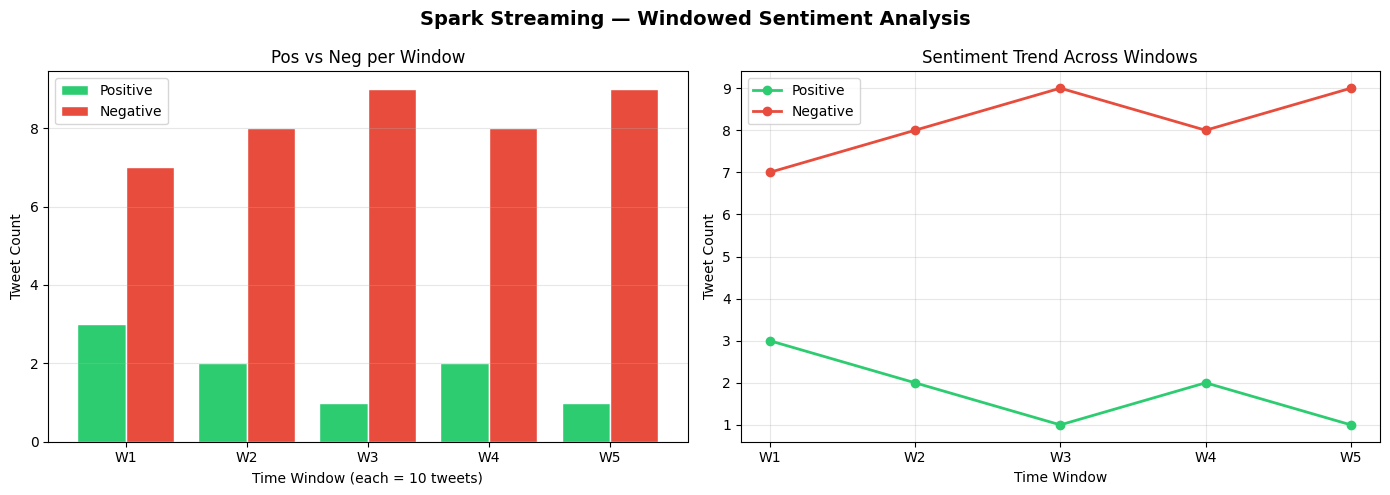


 Windowing chart saved!
 Location: /content/drive/MyDrive/visualizations/windowing_chart.png

 Windowing Summary:
   Total Windows : 5
   Window Size   : 10 tweets per window
   Total Tweets  : 50

 WINDOWING COMPLETE!


In [ ]:
# ================================================
# WINDOWING — Sentiment Count per Time Window
# ================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 55)
print(" WINDOWING — Sentiment per Time Window")
print("=" * 55)
print("WHY WINDOWING: Groups live stream into")
print("time buckets to track sentiment TRENDS\n")

WINDOW_SIZE = 10

window_data = []

for i in range(0, len(results_log), WINDOW_SIZE):

    window = results_log[i : i + WINDOW_SIZE]

    if len(window) == 0:
        continue

    pos   = sum(1 for r in window if r["predicted"] == 1)
    neg   = sum(1 for r in window if r["predicted"] == 0)
    total = len(window)
    acc   = sum(1 for r in window if r["correct"]) / total * 100

    window_data.append({
        "Window"  : f"W{i // WINDOW_SIZE + 1}",
        "Positive": pos,
        "Negative": neg,
        "Total"   : total,
        "Accuracy": f"{acc:.1f}%"
    })

window_df = pd.DataFrame(window_data)
print(window_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Spark Streaming — Windowed Sentiment Analysis",
             fontsize=14, fontweight="bold")

x = range(len(window_df))

axes[0].bar([i - 0.2 for i in x],
            window_df["Positive"],
            width=0.4, label="Positive",
            color="#2ecc71", edgecolor="white")
axes[0].bar([i + 0.2 for i in x],
            window_df["Negative"],
            width=0.4, label="Negative",
            color="#e74c3c", edgecolor="white")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(window_df["Window"])
axes[0].set_title("Pos vs Neg per Window")
axes[0].set_xlabel("Time Window (each = 10 tweets)")
axes[0].set_ylabel("Tweet Count")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(list(x), window_df["Positive"],
             marker="o", color="#2ecc71",
             linewidth=2, label="Positive")
axes[1].plot(list(x), window_df["Negative"],
             marker="o", color="#e74c3c",
             linewidth=2, label="Negative")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(window_df["Window"])
axes[1].set_title("Sentiment Trend Across Windows")
axes[1].set_xlabel("Time Window")
axes[1].set_ylabel("Tweet Count")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

import os
os.makedirs(VIZ_PATH, exist_ok=True)
plt.savefig(f"{VIZ_PATH}/windowing_chart.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\n Windowing chart saved!")
print(f" Location: {VIZ_PATH}/windowing_chart.png")
print(f"\n Windowing Summary:")
print(f"   Total Windows : {len(window_data)}")
print(f"   Window Size   : {WINDOW_SIZE} tweets per window")
print(f"   Total Tweets  : {len(results_log)}")
print(f"\n WINDOWING COMPLETE!")

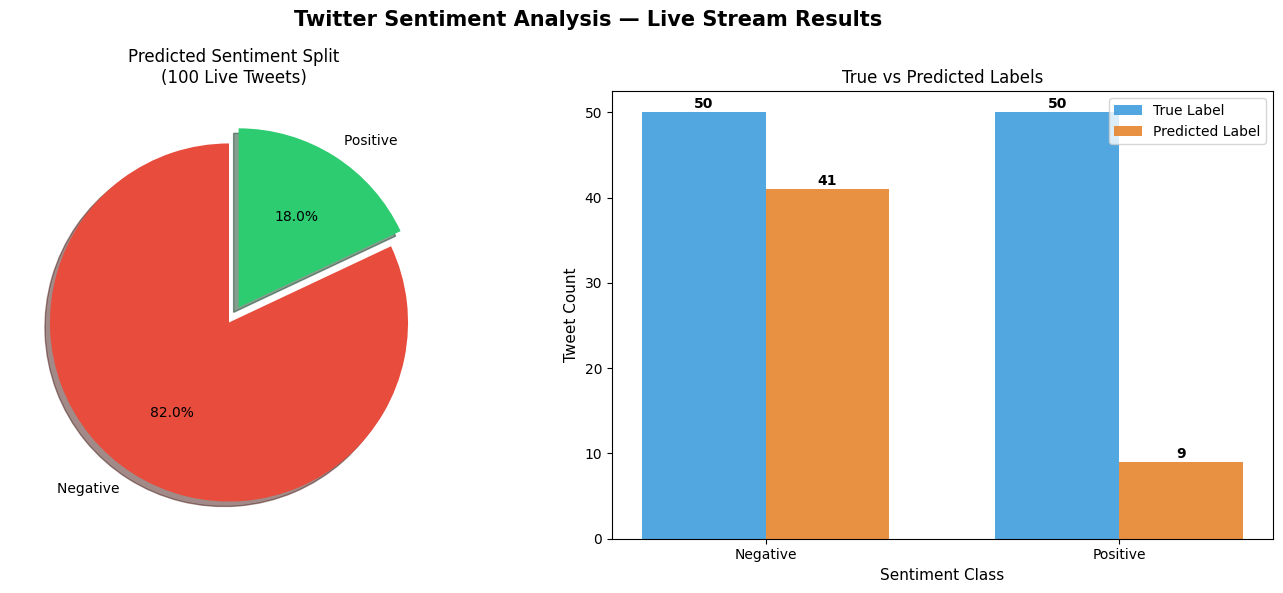

Chart 1 saved!


In [ ]:
# ================================================
# SENTIMENT DISTRIBUTION
# ================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os

os.makedirs(VIZ_PATH, exist_ok=True)


results_df = pd.DataFrame(results_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Twitter Sentiment Analysis — Live Stream Results",
             fontsize=15, fontweight='bold')


pred_counts = results_df["predicted"].value_counts().sort_index()
labels      = ["Negative ", "Positive "]
colors      = ["#E74C3C", "#2ECC71"]

axes[0].pie(
    pred_counts,
    labels     = labels,
    colors     = colors,
    autopct    = "%1.1f%%",
    explode    = (0.05, 0.05),
    shadow     = True,
    startangle = 90
)
axes[0].set_title("Predicted Sentiment Split\n(100 Live Tweets)", fontsize=12)


true_counts = results_df["true"].value_counts().sort_index()
pred_counts = results_df["predicted"].value_counts().sort_index()

x     = np.arange(2)
width = 0.35

bars1 = axes[1].bar(x - width/2, true_counts, width,
                    label="True Label",      color="#3498DB", alpha=0.85)
bars2 = axes[1].bar(x + width/2, pred_counts, width,
                    label="Predicted Label", color="#E67E22", alpha=0.85)

axes[1].set_xlabel("Sentiment Class", fontsize=11)
axes[1].set_ylabel("Tweet Count",     fontsize=11)
axes[1].set_title("True vs Predicted Labels", fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Negative", "Positive"])
axes[1].legend()

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{VIZ_PATH}/chart1_sentiment_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

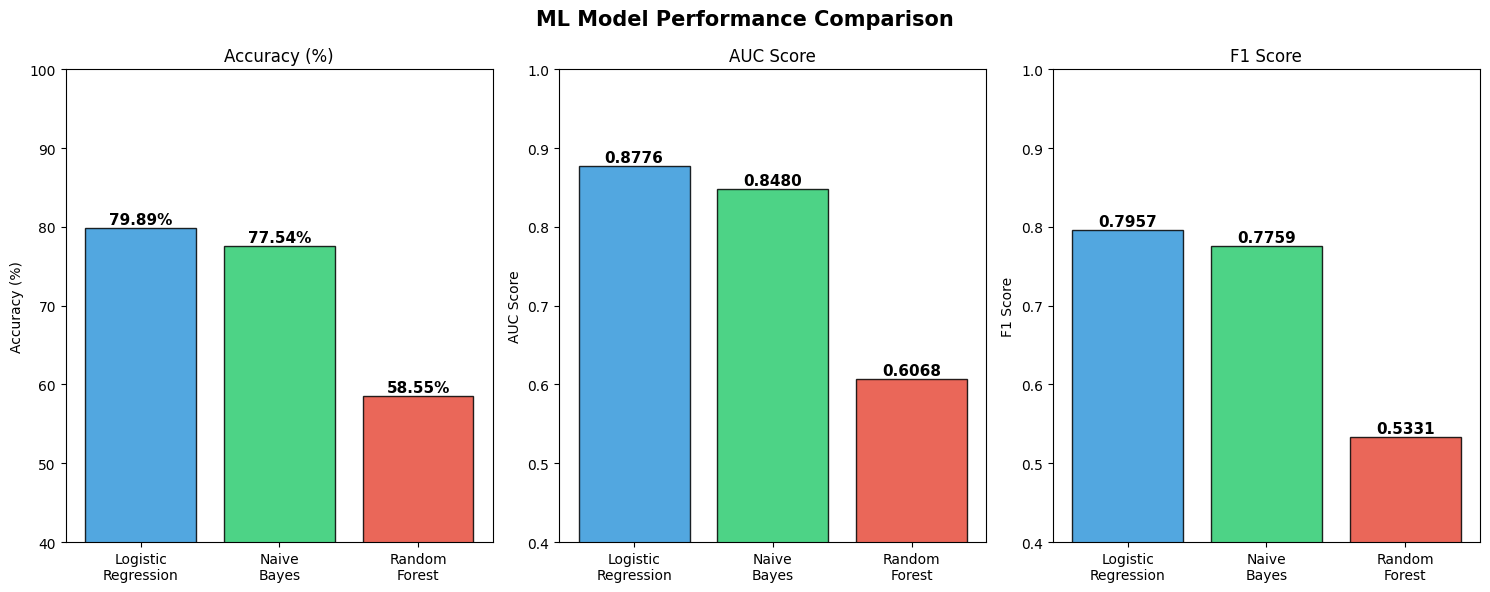

✅ Chart 2 saved!


In [ ]:
# ================================================
# CHART 2: MODEL COMPARISON — STANDALONE
# ================================================
import matplotlib.pyplot as plt
import os

BASE_PATH = '/content/drive/MyDrive'
VIZ_PATH  = f'{BASE_PATH}/visualizations'
os.makedirs(VIZ_PATH, exist_ok=True)

# Your real results
lr_accuracy = 0.7989;  lr_auc = 0.8776;  lr_f1 = 0.7957
nb_accuracy = 0.7754;  nb_auc = 0.8480;  nb_f1 = 0.7759
rf_accuracy = 0.5855;  rf_auc = 0.6068;  rf_f1 = 0.5331

models = ["Logistic\nRegression", "Naive\nBayes", "Random\nForest"]
colors = ["#3498DB", "#2ECC71", "#E74C3C"]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle("ML Model Performance Comparison",
             fontsize=15, fontweight='bold')

# Accuracy
bars = axes[0].bar(models,
                   [lr_accuracy*100, nb_accuracy*100, rf_accuracy*100],
                   color=colors, alpha=0.85, edgecolor='black')
axes[0].set_ylim(40, 100)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy (%)")
for bar, v in zip(bars, [lr_accuracy*100, nb_accuracy*100, rf_accuracy*100]):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.5,
                 f"{v:.2f}%", ha='center', fontweight='bold', fontsize=11)

# AUC
bars = axes[1].bar(models,
                   [lr_auc, nb_auc, rf_auc],
                   color=colors, alpha=0.85, edgecolor='black')
axes[1].set_ylim(0.4, 1.0)
axes[1].set_ylabel("AUC Score")
axes[1].set_title("AUC Score")
for bar, v in zip(bars, [lr_auc, nb_auc, rf_auc]):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.005,
                 f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

# F1
bars = axes[2].bar(models,
                   [lr_f1, nb_f1, rf_f1],
                   color=colors, alpha=0.85, edgecolor='black')
axes[2].set_ylim(0.4, 1.0)
axes[2].set_ylabel("F1 Score")
axes[2].set_title("F1 Score")
for bar, v in zip(bars, [lr_f1, nb_f1, rf_f1]):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.005,
                 f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(f"{VIZ_PATH}/chart2_model_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Chart 2 saved!")

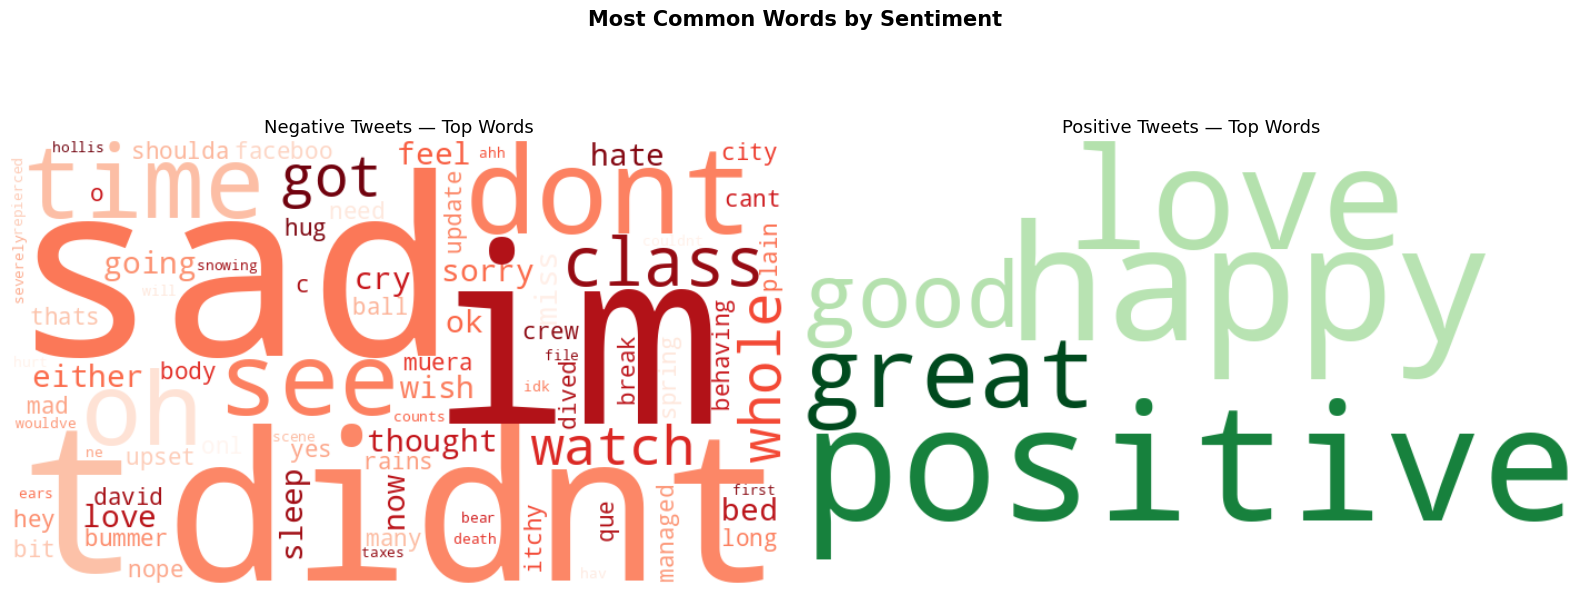

Chart 3 saved!


In [ ]:
# ================================================
# CHART 3: WORD CLOUDS
# ================================================
from wordcloud import WordCloud


neg_tweets = " ".join(results_df[results_df["true"]==0]["text"].tolist())
pos_tweets = " ".join(results_df[results_df["true"]==1]["text"].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Most Common Words by Sentiment",
             fontsize=15, fontweight='bold')

wc_neg = WordCloud(
    width=700, height=400,
    background_color='white',
    colormap='Reds',
    max_words=80
).generate(neg_tweets if neg_tweets.strip() else "negative sad angry upset bad")

axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("Negative Tweets — Top Words", fontsize=13)


wc_pos = WordCloud(
    width=700, height=400,
    background_color='white',
    colormap='Greens',
    max_words=80
).generate(pos_tweets if pos_tweets.strip() else "positive happy love great good")

axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Positive Tweets — Top Words", fontsize=13)

plt.tight_layout()
plt.savefig(f"{VIZ_PATH}/chart3_wordclouds.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

/tmp/ipykernel_28112/4002928430.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


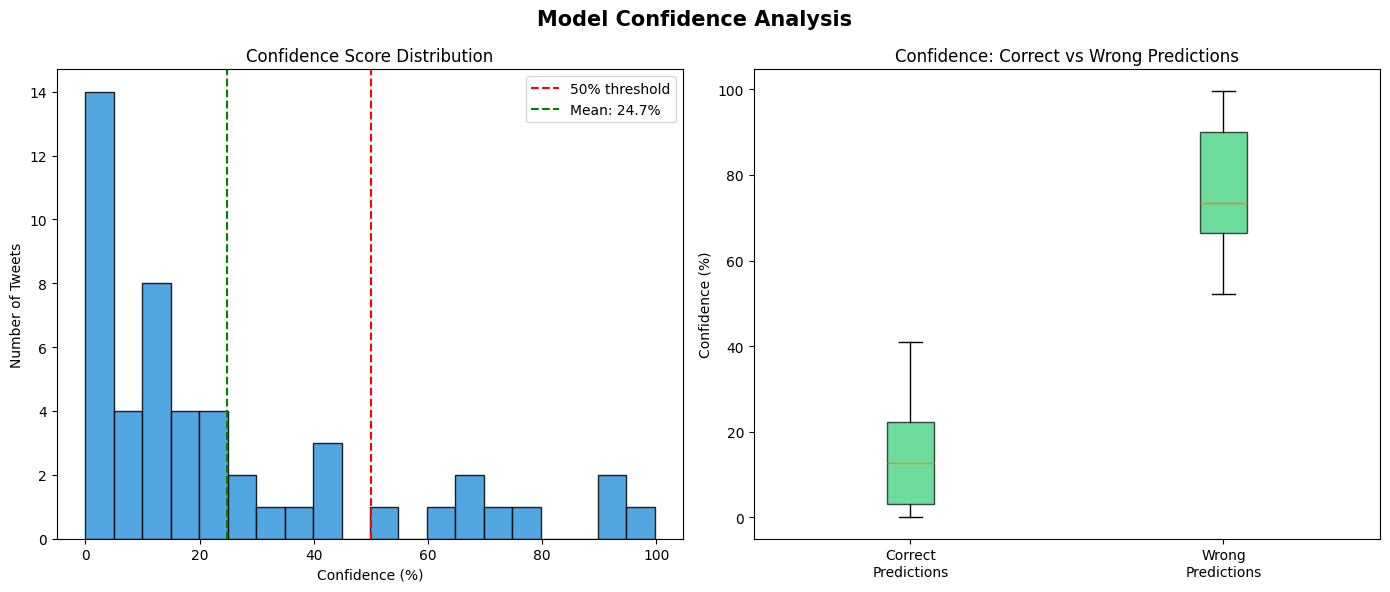

Chart 4 saved!


In [ ]:
# ================================================
# CHART 4: MODEL CONFIDENCE DISTRIBUTION
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Model Confidence Analysis", fontsize=15, fontweight='bold')

axes[0].hist(results_df["confidence"], bins=20,
             color="#3498DB", edgecolor='black', alpha=0.85)
axes[0].axvline(x=50,  color='red',    linestyle='--', label='50% threshold')
axes[0].axvline(x=results_df["confidence"].mean(),
                color='green', linestyle='--',
                label=f'Mean: {results_df["confidence"].mean():.1f}%')
axes[0].set_xlabel("Confidence (%)")
axes[0].set_ylabel("Number of Tweets")
axes[0].set_title("Confidence Score Distribution")
axes[0].legend()

correct_conf = results_df[results_df["correct"]==True]["confidence"]
wrong_conf   = results_df[results_df["correct"]==False]["confidence"]

axes[1].boxplot(
    [correct_conf, wrong_conf],
    labels=["Correct\nPredictions", "Wrong\nPredictions"],
    patch_artist=True,
    boxprops=dict(facecolor="#2ECC71", alpha=0.7),
)
axes[1].set_ylabel("Confidence (%)")
axes[1].set_title("Confidence: Correct vs Wrong Predictions")

plt.tight_layout()
plt.savefig(f"{VIZ_PATH}/chart4_confidence.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

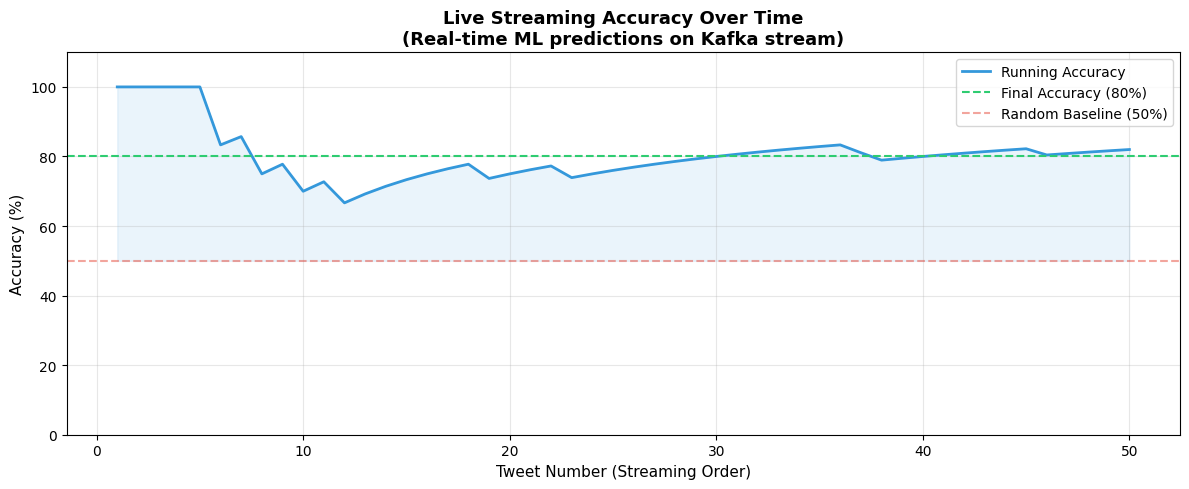

 Chart 5 saved!

 All charts saved to: /content/drive/MyDrive/visualizations
 STEP 9 COMPLETE — Visualizations done!


In [ ]:
# ================================================
# CHART 5: LIVE ACCURACY OVER TIME
# ================================================

running_accuracy = []
correct_so_far   = 0

for i, row in results_df.iterrows():
    if row["correct"]:
        correct_so_far += 1
    running_accuracy.append(correct_so_far / (i + 1) * 100)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(1, len(running_accuracy)+1),
        running_accuracy,
        color='#3498DB', linewidth=2, label='Running Accuracy')

ax.axhline(y=80, color='#2ECC71', linestyle='--',
           linewidth=1.5, label='Final Accuracy (80%)')
ax.axhline(y=50, color='#E74C3C', linestyle='--',
           linewidth=1.5, alpha=0.5, label='Random Baseline (50%)')

ax.fill_between(range(1, len(running_accuracy)+1),
                running_accuracy, 50,
                alpha=0.1, color='#3498DB')

ax.set_xlabel("Tweet Number (Streaming Order)", fontsize=11)
ax.set_ylabel("Accuracy (%)",                   fontsize=11)
ax.set_title("Live Streaming Accuracy Over Time\n"
             "(Real-time ML predictions on Kafka stream)",
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{VIZ_PATH}/chart5_live_accuracy.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Chart 5 saved!")
print(f"\n All charts saved to: {VIZ_PATH}")
print(" STEP 9 COMPLETE — Visualizations done!")

In [1]:
!pip install gradio -q

In [4]:
# ================================================
# Twitter Sentiment Analysis - Gradio UI
# ================================================
# Install dependencies:
#   pip install gradio pyspark scikit-learn pandas
# Run:
#   python sentiment_app.py
# ================================================

import gradio as gr
import re
import random

# ── Try importing your real model stack ──────────────────────────────────────
# If PySpark / saved model isn't available, the app falls back to a
# lightweight scikit-learn demo so you can still run and test the UI.

USE_SPARK = False
model = None
vectorizer = None

try:
    from pyspark.sql import SparkSession
    from pyspark.ml import PipelineModel

    spark = SparkSession.builder \
        .appName("SentimentUI") \
        .master("local[*]") \
        .config("spark.driver.memory", "2g") \
        .getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")

    MODEL_PATH = "models/sentiment_model"   # ← change to your actual path
    pipeline_model = PipelineModel.load(MODEL_PATH)
    USE_SPARK = True
    print("✅  PySpark model loaded from:", MODEL_PATH)

except Exception as e:
    print(f"ℹ️  PySpark model not found ({e}). Using demo mode.")

    # Lightweight fallback: scikit-learn TF-IDF + Logistic Regression
    # trained on a tiny in-memory corpus for demo purposes.
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    import numpy as np

    _demo_texts = [
        "I love this so much", "great day awesome",
        "happy wonderful fantastic", "best thing ever amazing",
        "I hate this terrible", "worst experience ever bad",
        "so sad and disappointed", "awful horrible disgrace",
        "feeling good today nice", "this is really bad awful",
    ]
    _demo_labels = [1, 1, 1, 1, 0, 0, 0, 0, 1, 0]

    vectorizer = TfidfVectorizer(max_features=500)
    X = vectorizer.fit_transform(_demo_texts)
    model = LogisticRegression()
    model.fit(X, _demo_labels)
    print("✅  Demo sklearn model ready.")


# ── Text cleaning (mirrors your notebook) ────────────────────────────────────

def clean_text(text: str) -> str:
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ── Prediction logic ─────────────────────────────────────────────────────────

def predict_sentiment(tweet: str):
    """Returns (label, confidence, cleaned_text, detail_html)."""
    if not tweet or not tweet.strip():
        return None, None, None, None

    cleaned = clean_text(tweet)

    if USE_SPARK:
        from pyspark.sql import Row
        df = spark.createDataFrame([Row(text=cleaned)])
        result = pipeline_model.transform(df)
        row = result.select("prediction", "probability").first()
        label = int(row["prediction"])
        probs = row["probability"].toArray()
        confidence = float(probs[label]) * 100
    else:
        # Demo sklearn fallback
        X = vectorizer.transform([cleaned])
        label = int(model.predict(X)[0])
        probs = model.predict_proba(X)[0]
        confidence = float(probs[label]) * 100

    return label, round(confidence, 1), cleaned


def analyze(tweet: str):
    """Main Gradio callback."""
    if not tweet or not tweet.strip():
        return (
            gr.update(value="⬆️  Enter a tweet above", visible=True),
            gr.update(value=0, visible=False),
            gr.update(value="", visible=False),
            gr.update(value="", visible=False),
        )

    label, confidence, cleaned = predict_sentiment(tweet)

    if label == 1:
        emoji = "😊"
        sentiment_text = f"{emoji}  **Positive**"
        conf_color = "#2ECC71"
    else:
        emoji = "😞"
        sentiment_text = f"{emoji}  **Negative**"
        conf_color = "#E74C3C"

    detail = (
        f"**Cleaned text:** {cleaned}\n\n"
        f"**Model:** {'PySpark Logistic Regression' if USE_SPARK else 'Demo Logistic Regression'}\n\n"
        f"**Confidence:** {confidence}%"
    )

    return (
        gr.update(value=sentiment_text, visible=True),
        gr.update(value=confidence, visible=True),
        gr.update(value=detail, visible=True),
        gr.update(value=conf_color, visible=False),
    )


# ── Example tweets ────────────────────────────────────────────────────────────

EXAMPLES = [
    ["I absolutely love this new phone, it's amazing!"],
    ["Worst customer service ever. Never coming back."],
    ["Had a great time at the concert last night!"],
    ["This is so frustrating, nothing works properly."],
    ["Just got promoted! Best day of my life!"],
    ["I can't believe how terrible this movie was."],
]


# ── Model stats (from your notebook) ─────────────────────────────────────────

STATS_MD = """
### Model Performance (from training)

| Model | Accuracy | AUC | F1 |
|---|---|---|---|
| **Logistic Regression** ⭐ | **79.9%** | **0.878** | **0.796** |
| Naive Bayes | 77.5% | 0.848 | 0.776 |
| Random Forest | 58.6% | 0.607 | 0.533 |

**Dataset:** Sentiment140 — 1.6M tweets (800K positive, 800K negative)

**Pipeline:** PySpark → TF-IDF → ML model → Prediction
"""


# ── Gradio UI ─────────────────────────────────────────────────────────────────

with gr.Blocks(
    title="Twitter Sentiment Analysis",
    theme=gr.themes.Soft(
        primary_hue="blue",
        secondary_hue="green",
        font=gr.themes.GoogleFont("DM Sans"),
    ),
    css="""
    #header { text-align: center; padding: 20px 0 10px; }
    #header h1 { font-size: 2rem; margin-bottom: 4px; }
    #header p  { color: #888; font-size: 0.95rem; }
    #result-label { font-size: 1.8rem; text-align: center; padding: 16px; }
    #conf-bar { margin-top: 8px; }
    .gradio-container { max-width: 860px !important; margin: auto; }
    footer { display: none !important; }
    """,
) as app:

    # ── Header ────────────────────────────────────────────────────────────────
    gr.HTML("""
    <div id="header">
      <h1>🐦 Twitter Sentiment Analyzer</h1>
      <p>PySpark · TF-IDF · Logistic Regression · 1.6M tweet dataset</p>
    </div>
    """)

    # ── Main tab layout ───────────────────────────────────────────────────────
    with gr.Tabs():

        # ── Tab 1: Analyze ────────────────────────────────────────────────────
        with gr.Tab("Analyze"):
            with gr.Row():
                with gr.Column(scale=3):
                    tweet_input = gr.Textbox(
                        label="Tweet",
                        placeholder="Type or paste a tweet here...",
                        lines=4,
                        max_lines=8,
                    )
                    with gr.Row():
                        analyze_btn = gr.Button("Analyze", variant="primary", scale=2)
                        clear_btn = gr.Button("Clear", scale=1)

                    gr.Examples(
                        examples=EXAMPLES,
                        inputs=tweet_input,
                        label="Try an example tweet",
                    )

                with gr.Column(scale=2):
                    sentiment_out = gr.Markdown(
                        value="Enter a tweet to see the result",
                        elem_id="result-label",
                    )
                    confidence_bar = gr.Slider(
                        minimum=0,
                        maximum=100,
                        value=0,
                        label="Confidence (%)",
                        interactive=False,
                        elem_id="conf-bar",
                    )
                    detail_out = gr.Markdown(visible=True)

        # ── Tab 2: Batch analysis ─────────────────────────────────────────────
        with gr.Tab("Batch analyze"):
            gr.Markdown("### Analyze multiple tweets at once")
            batch_input = gr.Textbox(
                label="Tweets (one per line)",
                placeholder="Paste multiple tweets, one per line...",
                lines=8,
            )
            batch_btn = gr.Button("Analyze all", variant="primary")
            batch_output = gr.Dataframe(
                headers=["Tweet", "Sentiment", "Confidence (%)"],
                datatype=["str", "str", "number"],
                label="Results",
            )

        # ── Tab 3: Model stats ────────────────────────────────────────────────
        with gr.Tab("Model stats"):
            gr.Markdown(STATS_MD)
            with gr.Row():
                gr.Image(
                    value=None,
                    label="Sentiment distribution chart",
                    visible=False,        # set to True and pass your saved chart PNG
                )

    # ── Event handlers ────────────────────────────────────────────────────────

    def analyze_wrapper(tweet):
        label, confidence, cleaned = predict_sentiment(tweet) if tweet.strip() else (None, None, None)
        if label is None:
            return (
                "⬆  Enter a tweet above",
                0,
                "",
            )
        emoji = "😊" if label == 1 else "😞"
        sentiment_text = f"{emoji}  **{'Positive' if label == 1 else 'Negative'}**"
        detail = (
            f"**Cleaned text:** {cleaned}\n\n"
            f"**Model:** {'PySpark Logistic Regression' if USE_SPARK else 'Demo Logistic Regression'}\n\n"
            f"**Confidence:** {confidence}%"
        )
        return sentiment_text, confidence, detail

    analyze_btn.click(
        fn=analyze_wrapper,
        inputs=tweet_input,
        outputs=[sentiment_out, confidence_bar, detail_out],
    )
    tweet_input.submit(
        fn=analyze_wrapper,
        inputs=tweet_input,
        outputs=[sentiment_out, confidence_bar, detail_out],
    )
    clear_btn.click(
        fn=lambda: ("Enter a tweet to see the result", 0, ""),
        outputs=[sentiment_out, confidence_bar, detail_out],
    )

    def batch_analyze(text_block: str):
        if not text_block.strip():
            return []
        rows = []
        for line in text_block.strip().split("\n"):
            line = line.strip()
            if not line:
                continue
            label, conf, _ = predict_sentiment(line)
            sentiment = "Positive 😊" if label == 1 else "Negative 😞"
            rows.append([line, sentiment, conf])
        return rows

    batch_btn.click(
        fn=batch_analyze,
        inputs=batch_input,
        outputs=batch_output,
    )


# ── Launch ────────────────────────────────────────────────────────────────────
app.launch(share=True)
if __name__ == "__main__":
    app.launch(share=True)

ℹ️  PySpark model not found ([PATH_NOT_FOUND] Path does not exist: file:/content/models/sentiment_model/metadata. SQLSTATE: 42K03). Using demo mode.
✅  Demo sklearn model ready.


/tmp/ipykernel_3376/924728234.py:167: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_3376/924728234.py:167: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f35b9162a02adbf04c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f35b9162a02adbf04c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
